<a href="https://colab.research.google.com/github/DawiSyauqi/DIF60202_IP_2311532009/blob/main/Tugas_Image_Enhancement_Muhammad_Dawi_Syauqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

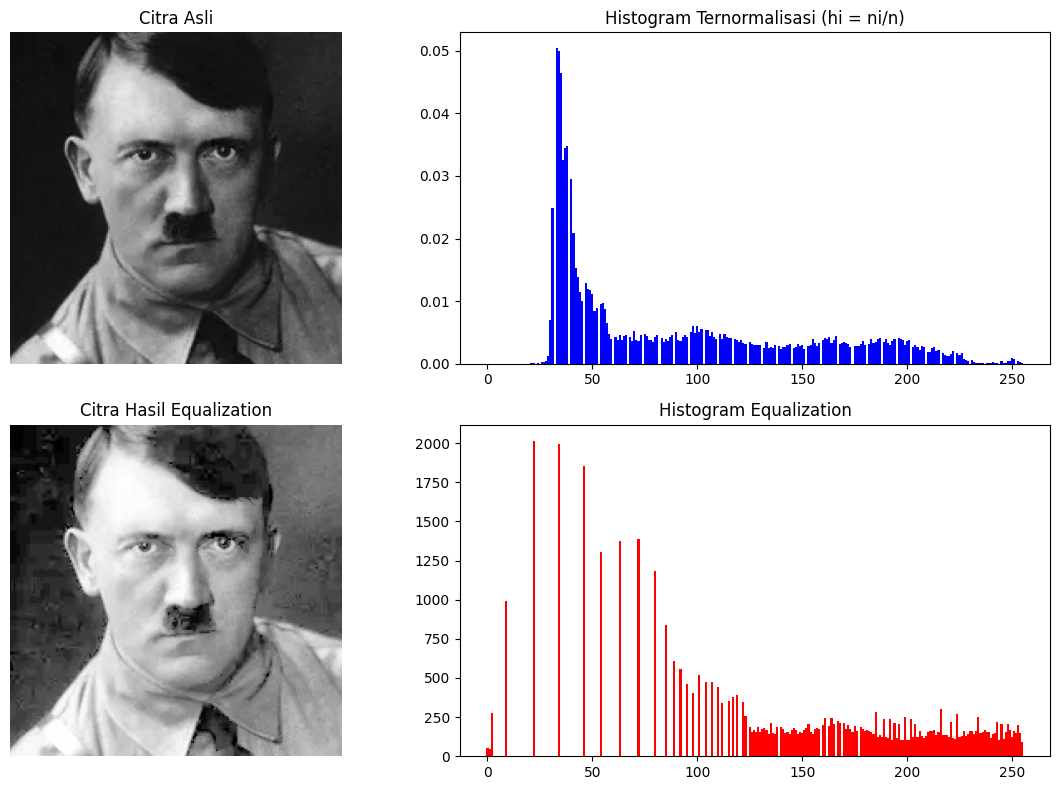

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Membaca Citra
img = cv2.imread('/content/Adolf-Hitler-1933.webp', cv2.IMREAD_GRAYSCALE)
tinggi, lebar = img.shape
total_piksel = tinggi * lebar

#Normalisasi Histogram
# a. Menghitung Histogram Asli
hist_asli = np.zeros(256, dtype=int)
for i in range(tinggi):
    for j in range(lebar):
        hist_asli[img[i, j]] += 1

# b. Normalisasi Histogram
hist_norm = np.zeros(256, dtype=float)
for i in range(256):
    hist_norm[i] = hist_asli[i] / total_piksel

# Histogram Equalization
# a. Menghitung Cumulative Distribution Function (CDF) dari histogram ternormalisasi
cdf = np.zeros(256, dtype=float)
cdf[0] = hist_norm[0]
for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist_norm[i]

# b. Membuat tabel pemetaan (Mapping) nilai piksel lama ke piksel baru
map_piksel = np.zeros(256, dtype=np.uint8)
for i in range(256):
    map_piksel[i] = np.round(cdf[i] * 255)

# c. Menerapkan pemetaan ke citra baru (Citra Ekualisasi)
img_eq = np.zeros((tinggi, lebar), dtype=np.uint8)
for i in range(tinggi):
    for j in range(lebar):
        img_eq[i, j] = map_piksel[img[i, j]]

# d. Menghitung Histogram Citra Hasil Ekualisasi (Untuk divisualisasikan)
hist_eq = np.zeros(256, dtype=int)
for i in range(tinggi):
    for j in range(lebar):
        hist_eq[img_eq[i, j]] += 1

# Visualisasi Hasil
plt.figure(figsize=(12, 8))

# Gambar Asli
plt.subplot(2, 2, 1)
plt.title("Citra Asli")
plt.imshow(img, cmap='gray')
plt.axis('off')

# Histogram Ternormalisasi
plt.subplot(2, 2, 2)
plt.title("Histogram Ternormalisasi (hi = ni/n)")
plt.bar(range(256), hist_norm, width=1, color='blue')

# Gambar Hasil Equalization
plt.subplot(2, 2, 3)
plt.title("Citra Hasil Equalization")
plt.imshow(img_eq, cmap='gray')
plt.axis('off')

# Histogram Hasil Equalization
plt.subplot(2, 2, 4)
plt.title("Histogram Equalization")
plt.bar(range(256), hist_eq, width=1, color='red')

plt.tight_layout()
plt.show()